# Estadística Bayesiana

La estadística bayesiana es un enfoque que interpreta la probabilidad como un grado de creencia o certeza sobre un evento, en lugar de verla únicamente como una frecuencia en el largo plazo.

A diferencia del enfoque frecuentista, donde los parámetros son valores fijos desconocidos, en el enfoque bayesiano los parámetros se tratan como variables aleatorias sobre las que se pueden hacer afirmaciones probabilísticas.

El elemento central es la regla de Bayes, que permite actualizar nuestras creencias iniciales (distribución a priori) con información proveniente de los datos (verosimilitud), obteniendo así una nueva distribución llamada posterior.

## Componentes principales

- Distribución a priori: Representa lo que se cree antes de observar los datos.  
- Verosimilitud: Refleja la información proporcionada por los datos.  
- Distribución posterior: Combina la información previa y los datos, representando el conocimiento actualizado.  

## Importancia

La inferencia bayesiana permite estimar parámetros, intervalos y probabilidades de forma coherente. Es especialmente útil en áreas como los seguros y la actuaría, donde la incertidumbre y la actualización de información son fundamentales.n fundamentales.

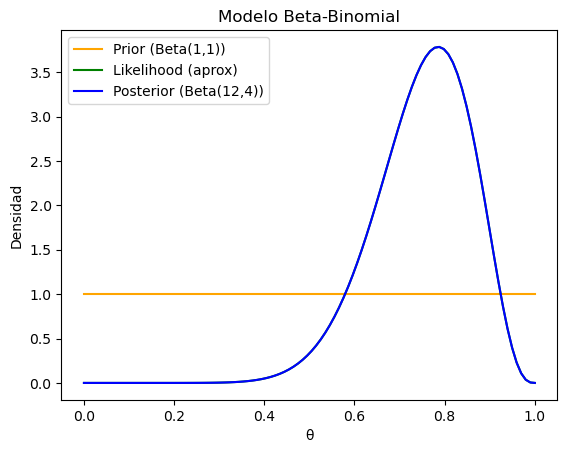

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Parámetros
N = 14
z = 11
a = 1
b = 1

# Rango de valores
x = np.linspace(0, 1, 100)

# Funciones
prior = beta.pdf(x, a, b)
likelihood = beta.pdf(x, z + 1, N - z + 1)   # aproximación
posterior = beta.pdf(x, a + z, b + N - z)

# Gráfica
plt.figure()

plt.plot(x, prior, color='orange', label='Prior (Beta(1,1))')
plt.plot(x, likelihood, color='green', label='Likelihood (aprox)')
plt.plot(x, posterior, color='blue', label='Posterior (Beta(12,4))')

plt.title("Modelo Beta-Binomial")
plt.xlabel("θ")
plt.ylabel("Densidad")
plt.legend()

plt.show()

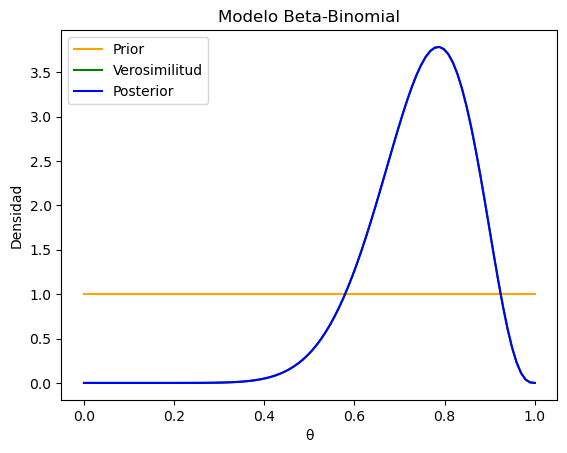

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# Parámetros
N = 14
z = 11
a = 1
b = 1

# Rango
x = np.linspace(0, 1, 100)

# Distribuciones
prior = beta.pdf(x, a, b)
likelihood = beta.pdf(x, z + 1, N - z + 1)
posterior = beta.pdf(x, a + z, b + N - z)

# Gráfica
plt.plot(x, prior, label="Prior", color="orange")
plt.plot(x, likelihood, label="Verosimilitud", color="green")
plt.plot(x, posterior, label="Posterior", color="blue")

plt.title("Modelo Beta-Binomial")
plt.xlabel("θ")
plt.ylabel("Densidad")
plt.legend()

plt.show()

# Intervalos de probabilidad, predicción y MCMC

En estadística bayesiana, la distribución posterior resume nuestro conocimiento actualizado sobre un parámetro después de observar los datos. Una forma de interpretarla es mediante intervalos de probabilidad, que indican qué valores del parámetro son creíbles.

Un intervalo del 95% contiene los valores más plausibles según la distribución posterior. En el caso de una distribución Beta(z+a, N-z+b), este intervalo se obtiene a partir de los cuantiles 2.5% y 97.5%.

Además, la distribución posterior permite hacer predicciones. La probabilidad de un nuevo evento se calcula como:

p(y=1) = (z + a) / (N + a + b)

Esto significa que la predicción corresponde a la media de la distribución posterior.

## Método de Metrópolis (MCMC)

En situaciones donde no es posible utilizar modelos conjugados o métodos simples, se emplean técnicas de simulación como los métodos de Monte Carlo vía Cadenas de Markov (MCMC).

El algoritmo de Metrópolis permite generar muestras de la distribución posterior sin conocer su forma exacta, utilizando únicamente la verosimilitud y la distribución inicial (hasta una constante de proporcionalidad).

## Caminata aleatoria

El algoritmo de Metrópolis puede entenderse como una caminata aleatoria:

- Se propone un nuevo valor del parámetro cercano al actual.  
- Si el nuevo valor tiene mayor probabilidad, se acepta.  
- Si tiene menor probabilidad, se acepta con cierta probabilidad.  

La probabilidad de aceptación es:

p_mover = P_propuesta / P_actual

A largo plazo, este proceso genera muestras que siguen la distribución posterior, permitiendo aproximarla incluso en problemas complejos.

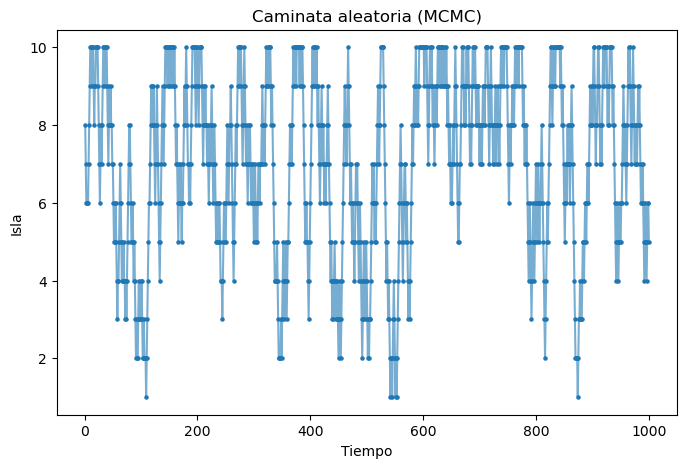

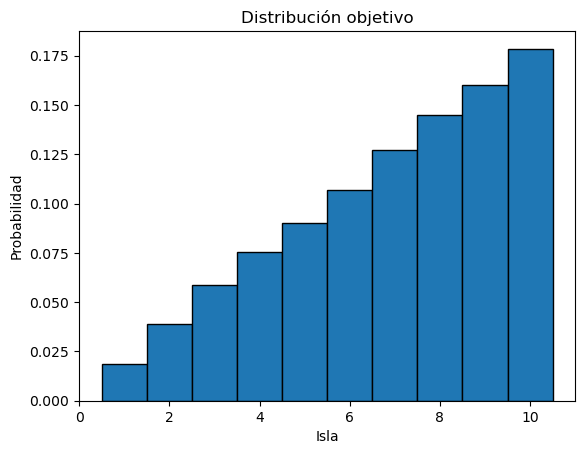

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos
islas = pd.DataFrame({
    "islas": np.arange(1, 11),
    "pob": np.arange(1, 11)
})

# Función de transición
def camina_isla(i):
    u = np.random.rand()
    v = i - 1 if u < 0.5 else i + 1

    # límites
    if v < 1 or v > 10:
        return i

    u2 = np.random.rand()
    p_move = min(islas.loc[v-1, "pob"] / islas.loc[i-1, "pob"], 1)

    return v if p_move > u2 else i

# Simulación
pasos = 100000
camino = np.zeros(pasos)
camino[0] = np.random.randint(1, 11)

for j in range(1, pasos):
    camino[j] = camina_isla(int(camino[j-1]))

# DataFrame
caminata = pd.DataFrame({
    "pasos": np.arange(1, pasos+1),
    "isla": camino
})

# 🔹 Gráfica caminata
plt.figure(figsize=(8,5))
plt.plot(caminata["pasos"][:1000], caminata["isla"][:1000], alpha=0.6)
plt.scatter(caminata["pasos"][:1000], caminata["isla"][:1000], s=5)
plt.title("Caminata aleatoria (MCMC)")
plt.xlabel("Tiempo")
plt.ylabel("Isla")
plt.show()

# HIST 
plt.figure()
plt.hist(caminata["isla"], bins=np.arange(1,12)-0.5, density=True, edgecolor='black')
plt.title("Distribución objetivo")
plt.xlabel("Isla")
plt.ylabel("Probabilidad")
plt.show()

# Martingalas

Una martingala es un proceso estocástico en el que el valor esperado futuro, condicionado a la información presente y pasada, es igual al valor actual. Es decir, no existe tendencia sistemática de crecimiento o disminución.

Matemáticamente:
E(X_{t+1} | X_t, X_{t-1}, ...) = X_t

## Interpretación

Las martingalas representan un "juego justo", donde no hay ventaja ni desventaja. El mejor estimador del valor futuro es el valor presente.

## Ejemplo

Un ejemplo clásico es una caminata aleatoria donde en cada paso se suma +1 o -1 con la misma probabilidad. En este caso, la esperanza del cambio es cero, por lo que el proceso es una martingala.

## Relación con estadística bayesiana

En estadística bayesiana, ciertos procesos de actualización de creencias pueden comportarse como martingalas, ya que la esperanza condicional de las estimaciones futuras coincide con el valor actual.

## Aplicaciones

Las martingalas se utilizan en diversas áreas como:
- Modelos financieros
- Teoría de probabilidad
- Procesos de decisión
- Análisis de riesgos en seguros

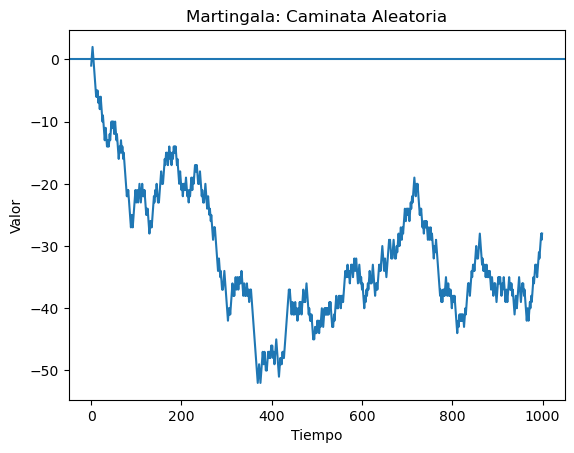

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
n = 1000  # número de pasos

# Generar pasos aleatorios (-1, +1)
pasos = np.random.choice([-1, 1], size=n)

# Caminata (martingala)
X = np.cumsum(pasos)

# Gráfica
plt.figure()
plt.plot(X)
plt.title("Martingala: Caminata Aleatoria")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.axhline(0)
plt.show()

In [43]:
# Esperanza aproximada del siguiente paso
esperanza = np.mean(pasos)

print("Esperanza de los incrementos:", esperanza)

Esperanza de los incrementos: -0.028


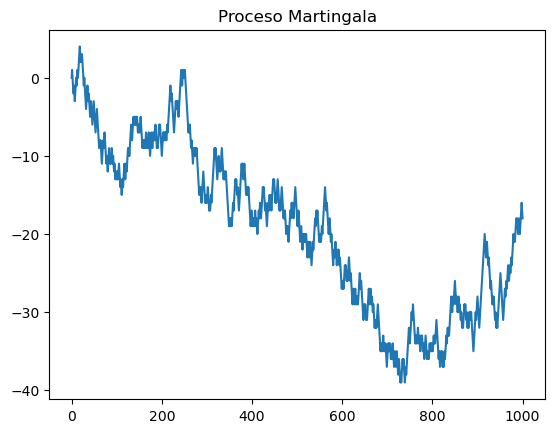

In [45]:
# Proceso con valor inicial
X = [0]

for i in range(n):
    incremento = np.random.choice([-1, 1])
    X.append(X[-1] + incremento)

X = np.array(X)

plt.plot(X)
plt.title("Proceso Martingala")
plt.show()